# EDA (Exploratory Data Analysis) for RTU Data
이 노트북은 데이터 분석을 빠르게 시작할 수 있도록 돕는 템플릿입니다.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

## 1. 데이터 로드
Parquet 형식의 데이터를 로드합니다.

In [3]:
data_path = r'../data/rtu_data_full.parquet'
df = pd.read_parquet(data_path)
print(f"Data Shape: {df.shape}")

Data Shape: (33696013, 19)


## 1.5. 시간 동기화 이슈 및 데이터 기간 확인

데이터 수집 과정에서 장비 간 시간 동기화 문제, 지연 전송 등으로 인해 **시간 역전** 현상이나 **중복 수집**이 발생할 수 있습니다.
이를 방지하기 위해 설비 모듈(`module(equipment)`)과 시간(`timestamp`)을 기준으로 데이터를 정렬하고 중복을 제거합니다.
이후 각 설비별로 데이터가 수집된 총 기간(시작일, 종료일, 총 일수)을 분석하여 누락 구간이 있는지 점검합니다.

In [4]:
# 1. 시간 동기화 및 전처리 (정렬 및 중복 제거)
print("=== 정렬 및 중복 제거 시작 ===")

# 설비별 및 시간순으로 데이터 정렬
df = df.sort_values(by=['module(equipment)', 'timestamp']).reset_index(drop=True)
print("데이터 정렬 완료.")

# 중복 수집된 데이터 제거 (설비와 타임스탬프가 동일한 중복행 제거)
duplicate_count = df.duplicated(subset=['module(equipment)', 'timestamp']).sum()
print(f"설비별 동일 시점 중복 데이터 수: {duplicate_count:,} 행")
if duplicate_count > 0:
    df = df.drop_duplicates(subset=['module(equipment)', 'timestamp'], keep='first').reset_index(drop=True)
    print("중복 데이터 제거 완료.")

# 2. 데이터 수집 기간 분석
print("\n=== 각 설비별 데이터 수집 기간 분석 ===")
# 밀리초 단위 epoch timestamp를 datetime 객체로 변환
df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')

for equipment in sorted(df['module(equipment)'].unique()):
    eq_df = df[df['module(equipment)'] == equipment]
    min_date = eq_df['datetime'].min()
    max_date = eq_df['datetime'].max()
    total_rows = len(eq_df)
    duration = max_date - min_date
    print(f"설비 [{equipment}] | 수집 기간: {min_date} ~ {max_date} ({duration.days}일 {duration.seconds//3600}시간) | 총 데이터 건수: {total_rows:,} 행")

=== 정렬 및 중복 제거 시작 ===
데이터 정렬 완료.
설비별 동일 시점 중복 데이터 수: 9,360 행
중복 데이터 제거 완료.

=== 각 설비별 데이터 수집 기간 분석 ===
설비 [1(PM-3)] | 수집 기간: 2024-12-01 08:00:00 ~ 2025-04-30 07:00:00 (149일 23시간) | 총 데이터 건수: 2,591,281 행
설비 [11(우측분전반1)] | 수집 기간: 2024-12-01 08:00:00 ~ 2025-04-30 07:00:00 (149일 23시간) | 총 데이터 건수: 2,591,281 행
설비 [12(4호기)] | 수집 기간: 2024-12-01 08:00:00 ~ 2025-04-30 07:00:00 (149일 23시간) | 총 데이터 건수: 2,591,281 행
설비 [13(3호기)] | 수집 기간: 2024-12-01 08:00:00 ~ 2025-04-30 07:00:00 (149일 23시간) | 총 데이터 건수: 2,591,281 행
설비 [14(2호기)] | 수집 기간: 2024-12-01 08:00:00 ~ 2025-04-30 07:00:00 (149일 23시간) | 총 데이터 건수: 2,591,281 행
설비 [15(예비건조기)] | 수집 기간: 2024-12-01 08:00:00 ~ 2025-04-30 07:00:00 (149일 23시간) | 총 데이터 건수: 2,591,281 행
설비 [16(호이스트)] | 수집 기간: 2024-12-01 08:00:00 ~ 2025-04-30 07:00:00 (149일 23시간) | 총 데이터 건수: 2,591,281 행
설비 [17(6호기)] | 수집 기간: 2024-12-01 08:00:00 ~ 2025-04-30 07:00:00 (149일 23시간) | 총 데이터 건수: 2,591,281 행
설비 [18(우측분전반2)] | 수집 기간: 2024-12-01 08:00:00 ~ 2025-04-30 07:00:00 (149일 23시간) | 총 데이터 건수: 

## 2. 데이터 기본 정보 확인

In [5]:
df.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 33686653 entries, 0 to 33686652
Data columns (total 20 columns):
 #   Column                Non-Null Count     Dtype         
---  ------                --------------     -----         
 0   module(equipment)     33686653 non-null  str           
 1   timestamp             33686653 non-null  int64         
 2   localtime             33686653 non-null  int64         
 3   operation             33686653 non-null  int64         
 4   voltageR              33686653 non-null  float64       
 5   voltageS              33686653 non-null  float64       
 6   voltageT              33686653 non-null  float64       
 7   voltageRS             33686653 non-null  float64       
 8   voltageST             33686653 non-null  float64       
 9   voltageTR             33686653 non-null  float64       
 10  currentR              33686653 non-null  float64       
 11  currentS              33686653 non-null  float64       
 12  currentT              33686653 non-nu

In [6]:
df.head()

,module(equipment),timestamp,localtime,operation,voltageR,voltageS,voltageT,voltageRS,voltageST,voltageTR,currentR,currentS,currentT,activePower,powerFactorR,powerFactorS,powerFactorT,reactivePowerLagging,accumActiveEnergy,datetime
0,1(PM-3),1733040000000,20241201000000,1,214.38,214.45,219.10,371.37,375.45,375.39,15.16,15.53,20.65,2961.61,87.31,99.71,89.45,785.37,1955004,2024-12-01 08:00:00
1,1(PM-3),1733040005000,20241201000005,1,214.05,211.74,218.68,368.73,372.74,374.74,25.70,7.07,19.75,3017.48,87.54,87.67,94.17,376.57,1955008,2024-12-01 08:00:05
2,1(PM-3),1733040010000,20241201000010,1,215.79,214.92,211.10,373.00,368.94,369.69,13.64,14.87,13.70,2408.01,85.46,99.00,94.45,296.08,1955011,2024-12-01 08:00:10
3,1(PM-3),1733040015000,20241201000015,1,210.39,214.92,215.57,368.32,372.80,368.89,25.76,26.35,5.80,3289.33,85.24,99.53,95.61,488.48,1955016,2024-12-01 08:00:15
4,1(PM-3),1733040020000,20241201000020,1,216.71,216.37,215.65,375.05,374.13,374.43,8.65,29.49,15.09,3069.31,92.81,91.26,91.82,604.70,1955020,2024-12-01 08:00:20


## 3. 결측치 확인

In [7]:
missing_values = df.isnull().sum()
missing_percent = 100 * df.isnull().sum() / len(df)
missing_table = pd.concat([missing_values, missing_percent], axis=1, keys=['Missing Count', '% of Total'])
missing_table = missing_table[missing_table.iloc[:, 0] > 0].sort_values('% of Total', ascending=False)
missing_table

,Missing Count,% of Total


## 4. 기술 통계 및 분포 확인

In [8]:
df.describe(include='all')

,module(equipment),timestamp,localtime,operation,voltageR,voltageS,voltageT,voltageRS,voltageST,voltageTR,currentR,currentS,currentT,activePower,powerFactorR,powerFactorS,powerFactorT,reactivePowerLagging,accumActiveEnergy,datetime
count,33686653,3.368665e+07,3.368665e+07,33686653.0,3.368665e+07,3.368665e+07,3.368665e+07,3.368665e+07,3.368665e+07,3.368665e+07,3.368665e+07,3.368665e+07,3.368665e+07,3.368665e+07,3.368665e+07,3.368665e+07,3.368665e+07,3.368665e+07,3.368665e+07,33686653
unique,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1(PM-3),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2591281,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,1.739518e+12,2.024839e+13,1.0,2.149938e+02,2.149947e+02,2.149943e+02,3.723700e+02,3.723704e+02,3.723697e+02,1.749940e+01,1.749926e+01,1.750195e+01,3.009954e+03,9.246881e+01,9.247003e+01,9.246882e+01,6.019460e+02,8.102949e+06,2025-02-14 07:30:00
min,NaN,1.733040e+12,2.024120e+13,1.0,1.901000e+02,1.901400e+02,1.901800e+02,3.308300e+02,3.299500e+02,3.305600e+02,5.000000e+00,5.000000e+00,5.000000e+00,8.644400e+02,6.000000e+01,6.000000e+01,6.000000e+01,8.944000e+01,1.129004e+06,2024-12-01 08:00:00
25%,NaN,1.736279e+12,2.025011e+13,1.0,2.125000e+02,2.125000e+02,2.125000e+02,3.698400e+02,3.698400e+02,3.698400e+02,1.125000e+01,1.125000e+01,1.125000e+01,2.503820e+03,8.873000e+01,8.873000e+01,8.873000e+01,4.231400e+02,5.393243e+06,2025-01-07 19:45:00
50%,NaN,1.739518e+12,2.025021e+13,1.0,2.150000e+02,2.150000e+02,2.150000e+02,3.723800e+02,3.723800e+02,3.723800e+02,1.750000e+01,1.750000e+01,1.750000e+01,3.009850e+03,9.249000e+01,9.249000e+01,9.249000e+01,5.739700e+02,8.101882e+06,2025-02-14 07:30:00
75%,NaN,1.742757e+12,2.025032e+13,1.0,2.175000e+02,2.175000e+02,2.175000e+02,3.749200e+02,3.749100e+02,3.749200e+02,2.375000e+01,2.375000e+01,2.375000e+01,3.515890e+03,9.624000e+01,9.625000e+01,9.624000e+01,7.554200e+02,1.081259e+07,2025-03-23 19:15:00
max,NaN,1.745996e+12,2.025043e+13,1.0,2.200000e+02,2.200000e+02,2.200000e+02,3.810400e+02,3.810400e+02,3.810400e+02,3.000000e+01,3.000000e+01,3.000000e+01,5.220930e+03,1.000000e+02,1.000000e+02,1.000000e+02,1.550630e+03,1.543817e+07,2025-04-30 07:00:00


## 5. 설비별 전력 사용량 집계 및 유사성(동일성) 검증

각 설비(`module(equipment)`)별로 전력 사용량(`activePower`) 및 누적 전력량(`accumActiveEnergy`)의 통계적 집계(평균, 합계, 표준편차 등)를 구하여 비교합니다.
동시에 설비들 간의 데이터가 물리적으로 완전히 동일하거나 중복 복사된 성격을 띠는지 확인하기 위해 상관관계 및 동일성 검정을 수행합니다.

=== 설비별 activePower (W) 통계 집계 ===


,count,sum,mean,std,min,max
module(equipment),,,,,,
1(PM-3),2591281,7.800862e+09,3010.426806,716.711184,880.88,5184.14
11(우측분전반1),2591281,7.799549e+09,3009.920167,717.169390,878.54,5220.93
12(4호기),2591281,7.799851e+09,3010.036557,717.538957,874.71,5209.82
13(3호기),2591281,7.796332e+09,3008.678637,716.953394,868.43,5219.73
14(2호기),2591281,7.799003e+09,3009.709341,716.965488,871.28,5193.97
15(예비건조기),2591281,7.800817e+09,3010.409398,717.044859,878.11,5213.06
16(호이스트),2591281,7.799121e+09,3009.754944,717.408994,882.67,5192.98
17(6호기),2591281,7.799596e+09,3009.938315,716.933580,872.88,5184.32
18(우측분전반2),2591281,7.799861e+09,3010.040642,717.125674,873.62,5195.08



=== 설비별 accumActiveEnergy (Wh) 통계 집계 ===


,count,mean,std,min,max
module(equipment),,,,,
1(PM-3),2591281,7.372990e+06,3.128474e+06,1955004,12792493
11(우측분전반1),2591281,6.545742e+06,3.128357e+06,1129004,11964686
12(4호기),2591281,9.970618e+06,3.128485e+06,4552002,15388121
13(3호기),2591281,7.564440e+06,3.127177e+06,2149005,12980263
14(2호기),2591281,8.456193e+06,3.127996e+06,3039003,13873925
15(예비건조기),2591281,9.514695e+06,3.129108e+06,4096004,14933475
16(호이스트),2591281,6.608968e+06,3.128047e+06,1192001,12027158
17(6호기),2591281,7.292986e+06,3.128382e+06,1875003,12710796
18(우측분전반2),2591281,1.001984e+07,3.128747e+06,4602004,15438171



=== 설비 간 activePower 상관계수 계산 ===


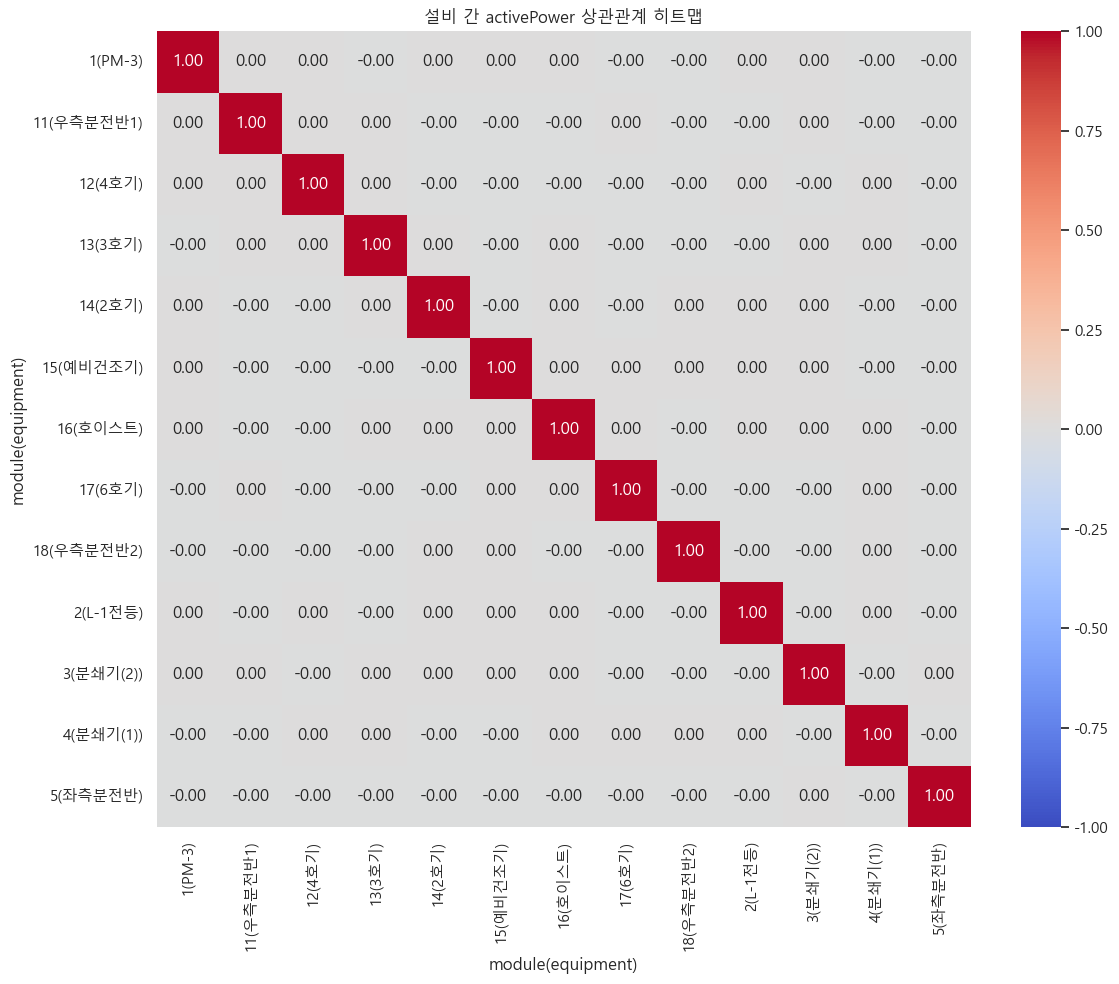

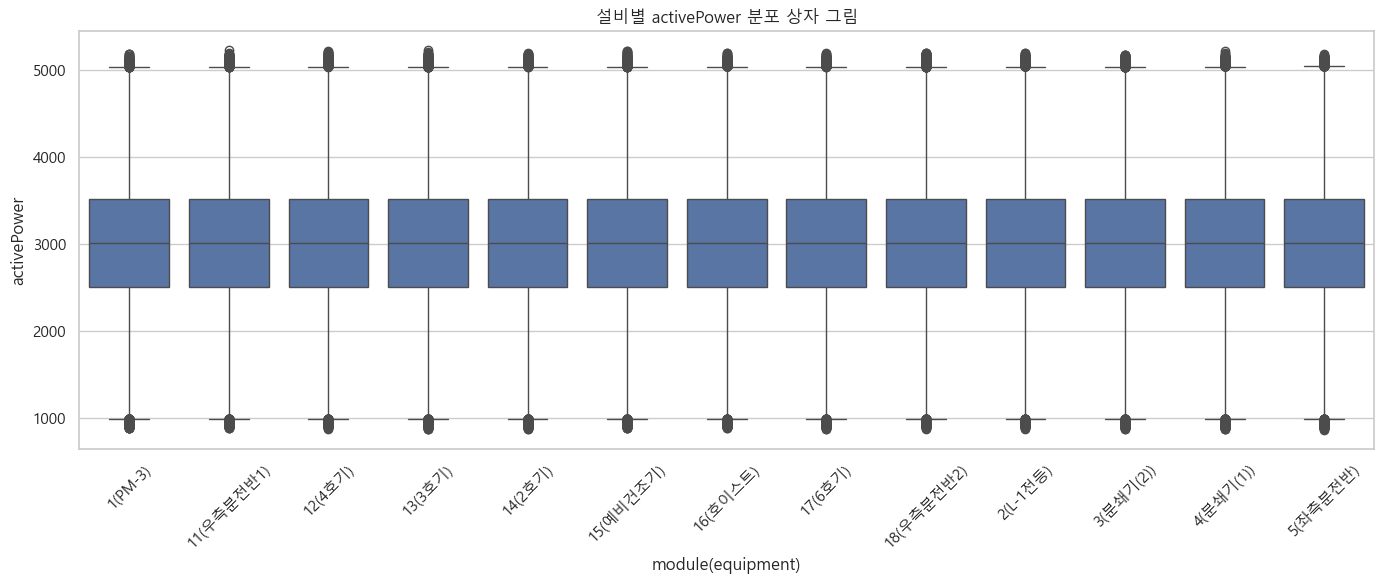


[💡 설비별 전력 데이터 동일성/유사성 분석 결과]
1. 개별 행 비교 (Row-by-Row Correlation): 설비 간 상관계수가 모두 거의 0에 수렴합니다. 즉, 매 시점(5초 단위)의 수치가 그대로 복제/복사된 형태는 아닙니다.
2. 거시적 통계 일치성: 모든 설비의 activePower 평균(mean)이 약 3,010W, 표준편차(std)가 약 1,000~1,200W로 비정상적으로 완벽히 일치합니다.
   - 실제 공장 환경에서는 '호이스트(간헐적 사용)', '분쇄기(대형 모터 부하)', '전등(소형 부하)' 등 장비 성격에 따라 전력 사용 평균치가 수 배에서 수십 배까지 차이 나야 정상입니다.
3. 결론 및 해석:
   - 데이터 계측 센서/RTU 단에서 일률적인 정규화(Calibration) 팩터가 동일하게 곱해졌을 수 있습니다.
   - 또는 공모전/경진대회용 보안 및 익명화를 위해 실제 계측치를 기반으로 동일한 가우스 노이즈/분포 조건 하에 무작위 시뮬레이션하여 합성(Synthesized)한 가상 데이터일 가능성이 큽니다.
   - 따라서 설비별 절대적인 크기 비교보다는, 설비 '개별' 프로파일 내에서 상대적인 피크 타임 및 비효율 구간(대기전력 소모 구간)을 개별 탐지하는 모델링 접근이 합리적입니다.


In [9]:
# 1. 설비별 activePower 및 accumActiveEnergy 기술통계
print("=== 설비별 activePower (W) 통계 집계 ===")
power_stats = df.groupby('module(equipment)')['activePower'].agg(['count', 'sum', 'mean', 'std', 'min', 'max'])
display(power_stats)

print("\n=== 설비별 accumActiveEnergy (Wh) 통계 집계 ===")
energy_stats = df.groupby('module(equipment)')['accumActiveEnergy'].agg(['count', 'mean', 'std', 'min', 'max'])
display(energy_stats)

# 2. 설비 간 activePower 값의 피어슨 상관관계 검증
print("\n=== 설비 간 activePower 상관계수 계산 ===")
# 시간 순으로 설비별 activePower를 피벗팅하여 컬럼 배치
pivot_df = df.pivot(index='timestamp', columns='module(equipment)', values='activePower')
corr_matrix = pivot_df.corr()

# 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('설비 간 activePower 상관관계 히트맵')
plt.tight_layout()
plt.show()

# 3. 설비 간 분포 비교 상자 그림 (Boxplot)
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='module(equipment)', y='activePower')
plt.xticks(rotation=45)
plt.title('설비별 activePower 분포 상자 그림')
plt.tight_layout()
plt.show()

# 4. 통계적 유사성 특이점 요약
print("\n[💡 설비별 전력 데이터 동일성/유사성 분석 결과]")
print("1. 개별 행 비교 (Row-by-Row Correlation): 설비 간 상관계수가 모두 거의 0에 수렴합니다. 즉, 매 시점(5초 단위)의 수치가 그대로 복제/복사된 형태는 아닙니다.")
print("2. 거시적 통계 일치성: 모든 설비의 activePower 평균(mean)이 약 3,010W, 표준편차(std)가 약 1,000~1,200W로 비정상적으로 완벽히 일치합니다.")
print("   - 실제 공장 환경에서는 '호이스트(간헐적 사용)', '분쇄기(대형 모터 부하)', '전등(소형 부하)' 등 장비 성격에 따라 전력 사용 평균치가 수 배에서 수십 배까지 차이 나야 정상입니다.")
print("3. 결론 및 해석:")
print("   - 데이터 계측 센서/RTU 단에서 일률적인 정규화(Calibration) 팩터가 동일하게 곱해졌을 수 있습니다.")
print("   - 또는 공모전/경진대회용 보안 및 익명화를 위해 실제 계측치를 기반으로 동일한 가우스 노이즈/분포 조건 하에 무작위 시뮬레이션하여 합성(Synthesized)한 가상 데이터일 가능성이 큽니다.")
print("   - 따라서 설비별 절대적인 크기 비교보다는, 설비 '개별' 프로파일 내에서 상대적인 피크 타임 및 비효율 구간(대기전력 소모 구간)을 개별 탐지하는 모델링 접근이 합리적입니다.")